In [1]:
import pandas as pd

df = pd.read_csv("../data/ecommerce_sales_data.csv")

In [2]:
#Remove Duplicate
df = df.drop_duplicates()

In [3]:
#Standardization of Column Names
df.columns = (
    df.columns
      .str.lower()
      .str.replace(" ", "_")
)

df.columns

Index(['order_date', 'product_name', 'category', 'region', 'quantity', 'sales',
       'profit'],
      dtype='object')

In [4]:
df.to_csv(
    "../data/ecommerce_data_clean.csv",
    index=False
)

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

df = pd.read_csv("../data/ecommerce_data_clean.csv")

df["order_date"] = pd.to_datetime(df["order_date"])

In [6]:
#Create column
df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month
df["month_name"] = df["order_date"].dt.strftime("%b")
df["quarter"] = df["order_date"].dt.quarter

df.head()

,order_date,product_name,category,region,quantity,sales,profit,year,month,month_name,quarter
0,2024-12-31,Printer,Office,North,4,3640,348.93,2024,12,Dec,4
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53,2022,11,Nov,4
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73,2022,5,May,2
3,2024-03-16,Mouse,Accessories,South,2,786,202.87,2024,3,Mar,1
4,2022-09-10,Mouse,Accessories,West,1,509,103.28,2022,9,Sep,3


In [7]:
#Business Metrics Statistic
total_revenue = df["sales"].sum()
total_profit = df["profit"].sum()
total_quantity = df["quantity"].sum()

print(f"Total Revenue : ${total_revenue:,.2f}")
print(f"Total Profit  : ${total_profit:,.2f}")
print(f"Total Quantity: {total_quantity:,}")

Total Revenue : $10,667,881.00
Total Profit  : $1,844,665.21
Total Quantity: 17,261


In [8]:
profit_margin = (total_profit / total_revenue) * 100

print(f"Profit Margin: {profit_margin:.2f}%")

Profit Margin: 17.29%


In [9]:
#Sales Analysis Trend
monthly_sales = (
    df.groupby(
        df["order_date"].dt.to_period("M")
    )["sales"]
    .sum()
    .reset_index()
)

In [10]:
monthly_sales["order_date"] = monthly_sales[
    "order_date"
].astype(str)

monthly_sales.head()

,order_date,sales
0,2022-01,341544
1,2022-02,208775
2,2022-03,294660
3,2022-04,230624
4,2022-05,314295


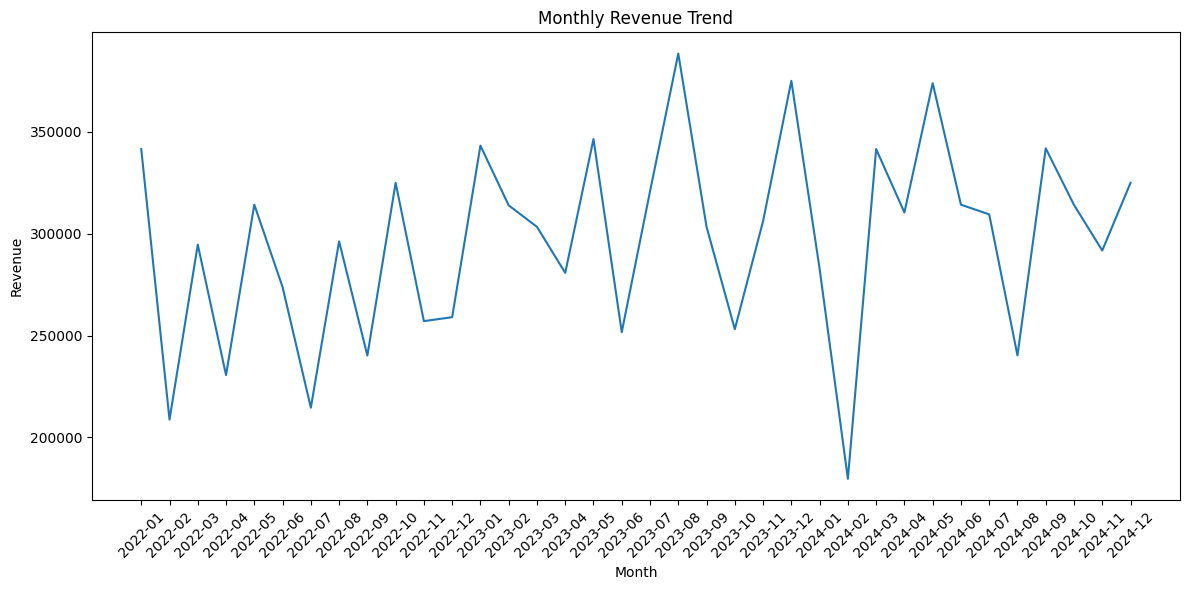

In [11]:
#VISUALISASI
plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales["order_date"],
    monthly_sales["sales"]
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [12]:
monthly_sales.nlargest(5, "sales")

,order_date,sales
19,2023-08,388428
23,2023-12,375064
28,2024-05,373911
16,2023-05,346481
12,2023-01,343256


In [13]:
monthly_sales.nsmallest(5, "sales")

,order_date,sales
25,2024-02,179708
1,2022-02,208775
6,2022-07,214627
3,2022-04,230624
8,2022-09,240211


### Key Insights

1. Monthly revenue is expected to remain stable during the 2022–2024 period, ranging from approximately 180,000 to 390,000.

2. There is no consistent year-over-year revenue growth trend, so the company needs to evaluate its strategies to drive long-term growth.

3. Several sales spikes occurred in August and December 2023, indicating seasonal factors or specific promotional programs.

4. February 2024 recorded the lowest revenue during the observation period and warrants further investigation.

In [14]:
#Category Analysis
category_sales = (
    df.groupby("category")["sales"]
    .sum()
    .sort_values(ascending=False)
)

category_sales

category
Electronics    5326074
Accessories    4247591
Office         1094216
Name: sales, dtype: int64

In [15]:
category_profit = (
    df.groupby("category")["profit"]
    .sum()
    .sort_values(ascending=False)
)

category_profit

category
Electronics    923185.59
Accessories    736084.74
Office         185394.88
Name: profit, dtype: float64

In [16]:
profit_margin_category = (
    df.groupby("category")
    .agg({
        "sales":"sum",
        "profit":"sum"
    })
)

profit_margin_category["margin_pct"] = (
    profit_margin_category["profit"]
    / profit_margin_category["sales"]
) * 100

profit_margin_category.sort_values(
    "margin_pct",
    ascending=False
)

,sales,profit,margin_pct
category,,,
Electronics,5326074,923185.59,17.333323
Accessories,4247591,736084.74,17.329464
Office,1094216,185394.88,16.943170


### Key Insight
1. Electronics is the company’s main revenue driver, accounting for nearly 50% of total revenue.
2. Profit follows revenue. The company’s profit structure depends heavily on sales volume, rather than on margin differences between categories.
3. All three categories have relatively uniform profit margins, indicating that pricing strategies and cost structures are likely applied consistently across all product categories.

In [17]:
#Distribution by Region
region_sales = (
    df.groupby("region")["sales"]
    .sum()
    .sort_values(ascending=False)
)

region_sales

region
West     2844450
East     2675110
South    2659548
North    2488773
Name: sales, dtype: int64

In [18]:
region_profit = (
    df.groupby("region")["profit"]
    .sum()
    .sort_values(ascending=False)
)

region_profit

region
West     495358.73
East     464888.46
South    458103.27
North    426314.75
Name: profit, dtype: float64

### Key Insight
1. The West Region is the largest contributor, accounting for approximately 26.7% of the company’s total revenue and generating the highest profit compared to other regions.
2. The company’s revenue is distributed fairly evenly across all regions, so the business is not overly dependent on any single region.
3. Differences in profit between regions are primarily due to sales volume, not differences in profit margins.

In [19]:
#Top 10 Product
top_products_sales = (
    df.groupby("product_name")["sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products_sales

product_name
Camera        1177381
Monitor       1160048
Printer       1094216
Mouse         1074398
Smartphone    1069681
Smartwatch    1049211
Keyboard      1024507
Tablet        1023928
Laptop        1005873
Headphones     988638
Name: sales, dtype: int64

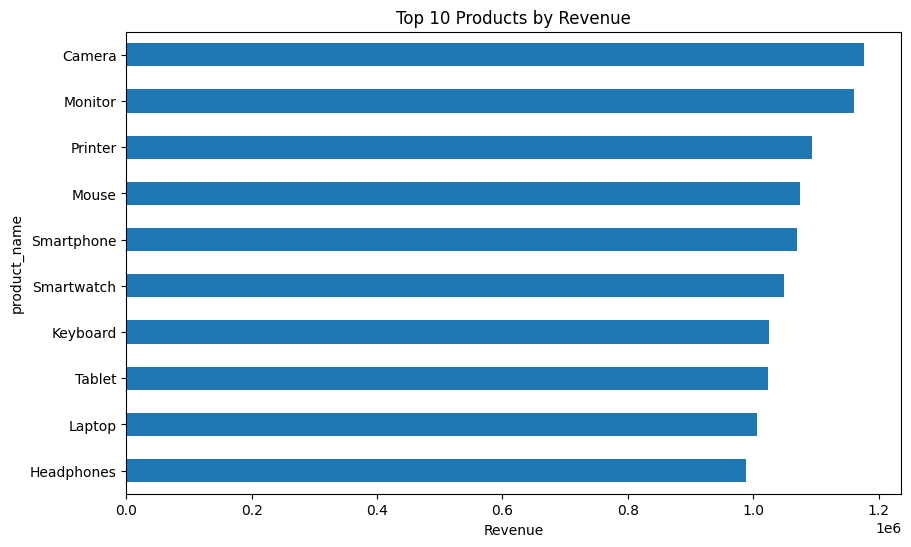

In [20]:
import matplotlib.pyplot as plt

top_products_sales.sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.show()

In [21]:
#Pareto Analysis
pareto = (
    df.groupby("product_name")["sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

In [22]:
pareto["cum_sales"] = pareto["sales"].cumsum()
pareto["cum_pct"] = pareto["cum_sales"] / pareto["sales"].sum() * 100

In [23]:
pareto.head(10)

,product_name,sales,cum_sales,cum_pct
0,Camera,1177381,1177381,11.036690
1,Monitor,1160048,2337429,21.910902
2,Printer,1094216,3431645,32.168010
3,Mouse,1074398,4506043,42.239344
4,Smartphone,1069681,5575724,52.266462
5,Smartwatch,1049211,6624935,62.101696
6,Keyboard,1024507,7649442,71.705356
7,Tablet,1023928,8673370,81.303588
8,Laptop,1005873,9679243,90.732574
9,Headphones,988638,10667881,100.000000


In [24]:
pareto_80 = pareto[pareto["cum_pct"] <= 80]

pareto_80

,product_name,sales,cum_sales,cum_pct
0,Camera,1177381,1177381,11.036690
1,Monitor,1160048,2337429,21.910902
2,Printer,1094216,3431645,32.168010
3,Mouse,1074398,4506043,42.239344
4,Smartphone,1069681,5575724,52.266462
5,Smartwatch,1049211,6624935,62.101696
6,Keyboard,1024507,7649442,71.705356


In [25]:
print("Total produk:", len(pareto))
print("Produk yang menyumbang 80% revenue:", len(pareto_80))
print("Persentase:", len(pareto_80) / len(pareto) * 100)

Total produk: 10
Produk yang menyumbang 80% revenue: 7
Persentase: 70.0


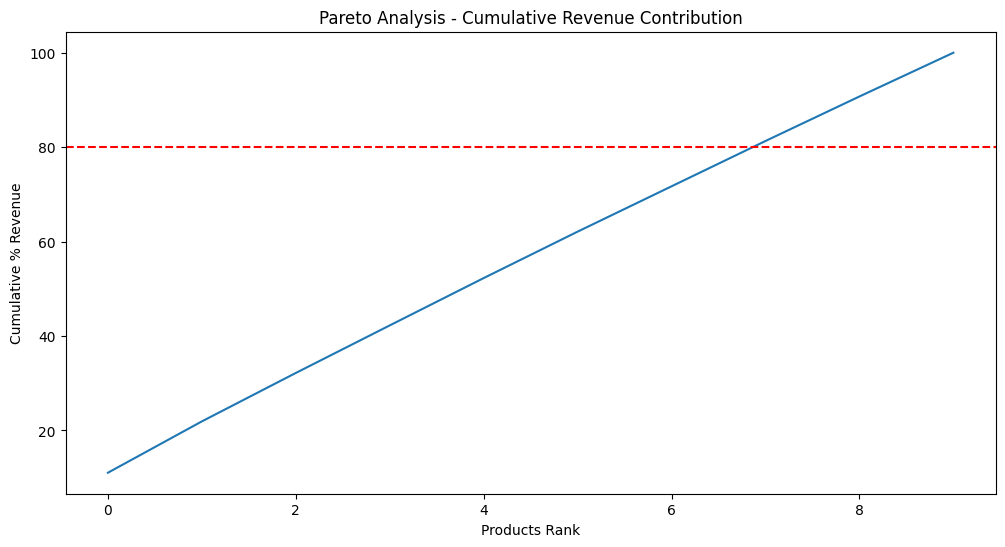

In [26]:
import numpy as np

plt.figure(figsize=(12,6))

plt.plot(pareto["cum_pct"])

plt.axhline(80, color="red", linestyle="--")

plt.title("Pareto Analysis - Cumulative Revenue Contribution")
plt.ylabel("Cumulative % Revenue")
plt.xlabel("Products Rank")

plt.show()

### Key Insight
1. Cameras were the top-revenue-generating product during the analysis period, followed by monitors and printers. These three products were the main contributors to the company’s revenue and played a key role in driving overall sales performance.
2. Revenue for all products ranged from approximately 988,000 to 1.18 million. No single product dominated the market to an extreme degree. All products demonstrated relatively balanced sales performance, indicating that the company does not rely on a single product as its primary source of revenue.
3. The Pareto analysis shows that the company’s revenue is not concentrated in a small subset of products. Instead, revenue contributions are distributed relatively evenly across the entire product portfolio.
4. Because revenue contributions are spread across various products, the company faces lower risk from a decline in the performance of any single product. This diversified revenue structure can help maintain business stability.